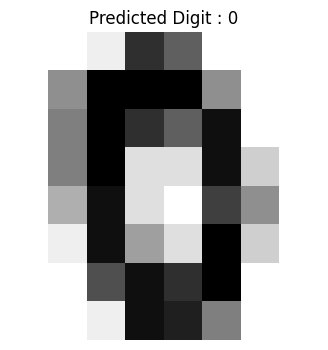

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5204 - loss: 1.7680 - val_accuracy: 0.8178 - val_loss: 0.9693
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8426 - loss: 0.6559 - val_accuracy: 0.8956 - val_loss: 0.3985
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8931 - loss: 0.3596 - val_accuracy: 0.9267 - val_loss: 0.2713
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9287 - loss: 0.2615 - val_accuracy: 0.9356 - val_loss: 0.2210
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9414 - loss: 0.2085 - val_accuracy: 0.9533 - val_loss: 0.1839
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9503 - loss: 0.1800 - val_accuracy: 0.9467 - val_loss: 0.1777
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9614 - loss: 0.1398 - val_accuracy: 0.9556 - val_loss: 0.1491
Epoch 8/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9629 - loss: 0.1243 - val_accuracy: 0.9600 - val_loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load handwritten digit dataset
digit_data = load_digits()

# Show one sample image
img_no = 72

plt.figure(figsize=(4, 4))
plt.imshow(digit_data.images[img_no], cmap='binary')
plt.title(f"Predicted Digit : {digit_data.target[img_no]}")
plt.axis('off')
plt.show()

# Input and output data
X = digit_data.data.astype("float32")
y = digit_data.target.astype("int32")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    shuffle=True,
    random_state=10
)

# Data normalization
normalizer = MinMaxScaler()

X_train = normalizer.fit_transform(X_train)
X_test = normalizer.transform(X_test)

# Convert labels into categorical format
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

# Create Neural Network
ann_model = Sequential()

ann_model.add(Dense(128, activation='relu', input_shape=(64,)))
ann_model.add(Dropout(0.2))

ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dense(10, activation='softmax'))

# Compile model
ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
training_history = ann_model.fit(
    X_train,
    y_train_encoded,
    epochs=25,
    batch_size=16,
    validation_data=(X_test, y_test_encoded),
    verbose=1
)

# Testing model
test_loss, test_accuracy = ann_model.evaluate(X_test, y_test_encoded)

print("\nFinal Test Loss :", test_loss)
print("Final Test Accuracy :", test_accuracy)

# Predict one sample
sample = X_test[5].reshape(1, 64)

prediction = ann_model.predict(sample)

print("Predicted Digit :", np.argmax(prediction))
print("Actual Digit :", y_test[5])